# **0. Import Library**

In [1]:
!pip install climada
!pip install fiona

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 778.9/778.9 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.3/172.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/

# **1. Calculate Rai Event loss to the attached random exposure, using embeded hazard and default damange function for PHL.**

Below Code Condtions

*   Exposure: Random_Exposure_PHL_withValue.shp

*   Embeded hazard: IBTRACS

*   Default damange function: from_calibrated_regional_impfset() with id=7 for PHL


In [30]:
import numpy as np
from climada.entity import Exposures, ImpactFuncSet, IFTropCyclone
from climada.entity.impact_funcs import ImpactFuncSet, ImpfTropCyclone
from climada.hazard import Centroids, TCTracks, TropCyclone
from climada.engine import ImpactCalc
from climada.engine import Impact
from climada.entity import LitPop
from climada.entity.impact_funcs.trop_cyclone import ImpfSetTropCyclone
import matplotlib.pyplot as plt

min_lat, max_lat, min_lon, max_lon = 8.587500000000006, 11.095833333333331, 118.55416666666667, 126.33749999999998
#min_lat, max_lat, min_lon, max_lon = 7.5, 12.5, 115, 127

In [31]:
import geopandas as gdf

exp_lp = gdf.read_file("Random_Exposure_PHL_withValue.shp")

print(exp_lp)

     rand_point iso3        status color_code         name continent  \
0           0.0  PHL  Member State        PHL  Philippines      Asia   
1           1.0  PHL  Member State        PHL  Philippines      Asia   
2           2.0  PHL  Member State        PHL  Philippines      Asia   
3           3.0  PHL  Member State        PHL  Philippines      Asia   
4           4.0  PHL  Member State        PHL  Philippines      Asia   
..          ...  ...           ...        ...          ...       ...   
995       995.0  PHL  Member State        PHL  Philippines      Asia   
996       996.0  PHL  Member State        PHL  Philippines      Asia   
997       997.0  PHL  Member State        PHL  Philippines      Asia   
998       998.0  PHL  Member State        PHL  Philippines      Asia   
999       999.0  PHL  Member State        PHL  Philippines      Asia   

                 region iso_3166_1   french_sho ExposureVa  Exposure_1  \
0    South-Eastern Asia         PH  Philippines       None   


*   **Check which column contain the exposure value**


*   then rename it into "value" to do the impact function



*   it should be "Exposure_1"




In [32]:
# Filter exposures to the specified bounds using a temporary GeoDataFrame
gdf_filtered = exp_lp[
    (exp_lp.geometry.y >= min_lat) &
    (exp_lp.geometry.y <= max_lat) &
    (exp_lp.geometry.x >= min_lon) &
    (exp_lp.geometry.x <= max_lon)
]

# Create a new Exposures object with the filtered GeoDataFrame
exp_lp = Exposures(gdf_filtered)
print(exp_lp)


description: None
ref_year: 2018
value_unit: USD
crs: EPSG:4326
data: (164 entries)
     rand_point iso3        status color_code         name continent  \
3           3.0  PHL  Member State        PHL  Philippines      Asia   
4           4.0  PHL  Member State        PHL  Philippines      Asia   
9           9.0  PHL  Member State        PHL  Philippines      Asia   
11         11.0  PHL  Member State        PHL  Philippines      Asia   
983       983.0  PHL  Member State        PHL  Philippines      Asia   
986       986.0  PHL  Member State        PHL  Philippines      Asia   
987       987.0  PHL  Member State        PHL  Philippines      Asia   
989       989.0  PHL  Member State        PHL  Philippines      Asia   

                 region iso_3166_1   french_sho ExposureVa  Exposure_1  \
3    South-Eastern Asia         PH  Philippines       None     10000.0   
4    South-Eastern Asia         PH  Philippines       None     10000.0   
9    South-Eastern Asia         PH  Philippin

**so Rename 'Exposure_1' to 'value' in this line**

**exp_lp.gdf.rename(columns={"Exposure_1": "value"}, inplace=True)**

Nearest neighbor hazard.centroids indexes for each exposure: [ 39401  20725 168200  41701 172086  66653 192373 194676  19860 149284
  13730   9193  23773  51845  15926  86934 110260  15925  43314  19828
  56545  93297  35943  95443  21581   2425  53833  39049 190720   6652
  82625 129739 132373 102507  34626  81447  56739 159637  57339 144569
  34744  16703 148469  89207   1381 109466 101284  71521 193698  32433
 159666  86175  73662 127676 117275  97775  92674 119594  16979  95624
 142478  50975  56791 149245 189785 150284  83916 146429  99432  10543
 107258  24790  62854   6843  96235 102606  79500 154996  54629 133160
 116468 165911   2945  11502 194608 102652  93267  75293 111195 189226
  46825  92716 148468 114519  89348  89348 174478  17209  45281 157019
  45320 139118 133663 186813  69066  21112 115304  84937  27015  17219
 105588 111198  18317  84559 185306  16727   9040  11526   2175 150318
   4246  28913  90299  59875  98934 179140  31247 142995 179839  50738
 130503  44148 1

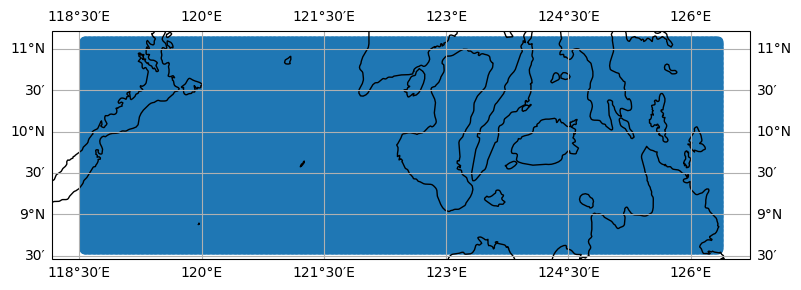

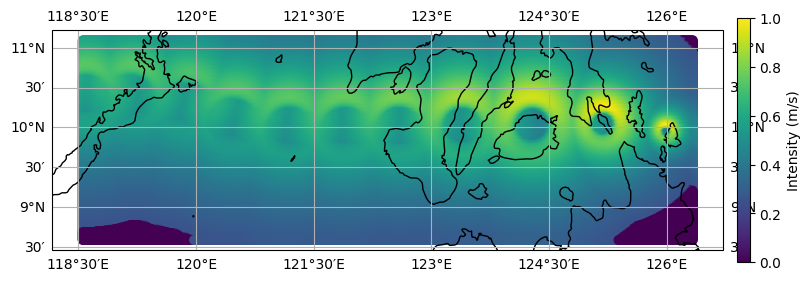

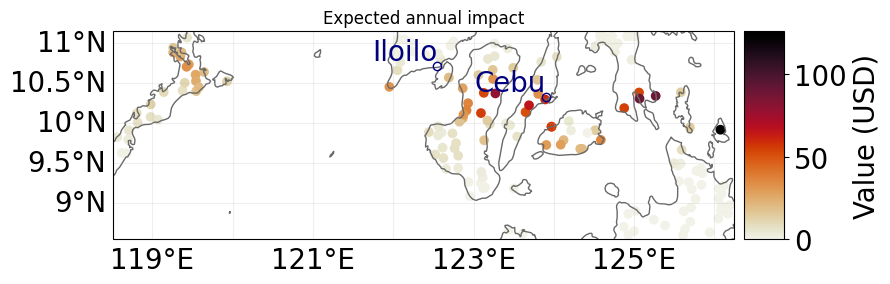

In [34]:
cent = Centroids.from_pnt_bounds((min_lon, min_lat, max_lon, max_lat), res=0.01)
cent.plot();

# compute Hazard in that centroids
tr_pnt = TCTracks.from_ibtracs_netcdf(storm_id="2021346N05145")
tc_pnt = TropCyclone.from_tracks(tr_pnt, centroids=cent)
tc_pnt.check()

ax_pnt = tc_pnt.centroids.plot(
    c=np.array(tc_pnt.intensity[0, :].todense()).squeeze()
)  # plot intensity per point
ax_pnt.get_figure().colorbar(
    ax_pnt.collections[0], fraction=0.0175, pad=0.02
).set_label(
    "Intensity (m/s)"
)  # add colorbar

# generate the default calibrated TC impact functions for different regions
imp_fun_set_TC = ImpfSetTropCyclone.from_calibrated_regional_ImpfSet()

impf_pnt = ImpactFuncSet()
impf_phl = imp_fun_set_TC.get_func(haz_type="TC", fun_id=7)  # ID 7 corresponds to Philippines (from Eberenz et al., 2021)
impf_pnt.append(impf_phl)
impf_pnt.check()
#impf_pnt.plot()

# Step 6: Assign impact function ID to exposures
haz_type = "TC"
haz_id = 7  # Philippines-specific impact function

# Rename 'Exposure_1' to 'value'
exp_lp.gdf.rename(columns={"Exposure_1": "value"}, inplace=True)
exp_lp.gdf.rename(columns={"impf_": f"impf_{haz_type}"}, inplace=True)
exp_lp.gdf[f"impf_{haz_type}"] = haz_id
exp_lp.check()

# Step 7: Compute economic impact tcpnt
imp_pnt = ImpactCalc(exp_lp, impf_pnt, tc_pnt).impact(save_mat=True)

print(
    "Nearest neighbor hazard.centroids indexes for each exposure:",
    exp_lp.gdf["centr_TC"].values,
)
imp_pnt.plot_scatter_eai_exposure(ignore_zero=False, buffer=0.05);

# Step 8: Output results
print(f"Total Economic Impact (USD): {imp_pnt.aai_agg:,.2f}")
print(f"Impact per event (USD): {imp_pnt.at_event[0]:,.2f}")
print(f"Sum of the direct impact at all exposure point: : {imp_pnt.eai_exp.sum():,.2f}")
print(f"total exposure value affected (USD): {imp_pnt.tot_value.sum():,.2f}")

# **2. Calculate Rai Event loss to the attached raondom exposure, using our own hazard with damage function Case X.**

Below Code Condtions

*   Exposure: Random_Exposure_PHL_withValue.shp

*   Embeded hazard: ERA5 LAND Wind Gust CSV

*   Default Impact function: CASE 4

Set intensity and MDD as below reference:

*   Below 17.5 m/s (tropical storm threshold): Minimal damage (MDD ≈ 0).

*   17.5–33 m/s (tropical storm to Category 1): Low to moderate damage (e.g., MDD = 0.05–0.15), as weaker structures (e.g., wooden houses, crops) start to fail.

*   33–50 m/s (Category 1–3): Significant damage (e.g., MDD = 0.15–0.4), reflecting damage to semi-permanent structures and agriculture.



*   Above 50 m/s (Category 3–5, including Rai’s peak): Near-total damage (MDD = 0.4–0.8), as most structures and crops are destroyed.


Set paa as below reference:  

since Rai’s gusts peak at ~75 m/s, we’ll cap the PAA at 1 for intensities ≥ 75 m/s to align with the storm’s characteristics.


*   0 m/s: No assets affected (PAA = 0).

*   17.5 m/s: 5% of assets affected (PAA = 0.05).


*   33 m/s: 15% affected.

*   50 m/s: 40% affected.

*   ≥75 m/s: 70% affected




/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py:3553: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  exec(code_obj, self.user_global_ns, self.user_ns)


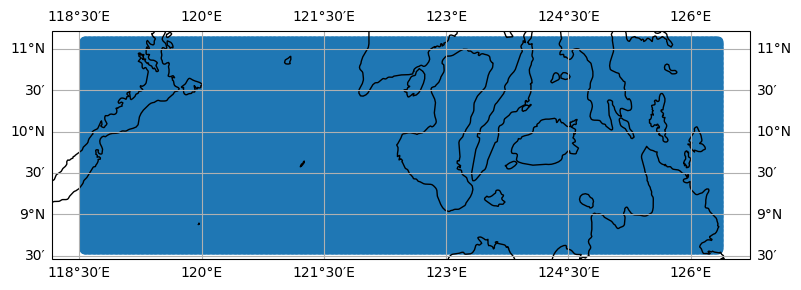

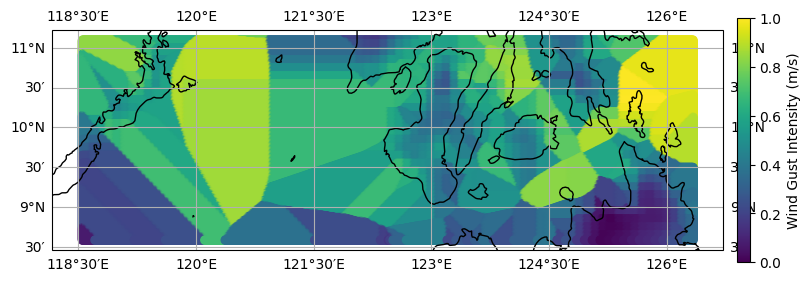

In [39]:
import numpy as np
import pandas as pd
import xarray as xr
from climada.entity import Exposures, ImpactFuncSet, IFTropCyclone
from climada.entity.impact_funcs import ImpactFuncSet, ImpfTropCyclone
from climada.hazard import Centroids, TCTracks, TropCyclone
from climada.engine import ImpactCalc
from climada.engine import Impact
from climada.entity import LitPop
from climada.entity.impact_funcs.trop_cyclone import ImpfSetTropCyclone
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
from scipy.sparse import csr_matrix

min_lat, max_lat, min_lon, max_lon = 8.587500000000006, 11.095833333333331, 118.55416666666667, 126.33749999999998
#min_lat, max_lat, min_lon, max_lon = 7.5, 12.5, 115, 127

import geopandas as gdf

exp_lp = gdf.read_file("Random_Exposure_PHL_withValue.shp")

# Filter exposures to the specified bounds using a temporary GeoDataFrame
gdf_filtered = exp_lp[
    (exp_lp.geometry.y >= min_lat) &
    (exp_lp.geometry.y <= max_lat) &
    (exp_lp.geometry.x >= min_lon) &
    (exp_lp.geometry.x <= max_lon)
]

# Create a new Exposures object with the filtered GeoDataFrame
exp_lp = Exposures(gdf_filtered)

cent = Centroids.from_pnt_bounds((min_lon, min_lat, max_lon, max_lat), res=0.01)
cent.plot();

# Step 4: Load wind gust data from CSV
wind_gust_df = pd.read_csv("max_wind_gust_2021346N05145.csv")

# Assume CSV has columns 'latitude', 'longitude', 'max_wind_gust'
# Verify column names with: print(wind_gust_df.columns)
wind_gust_points = wind_gust_df[['latitude', 'longitude']].values
wind_gust_values = wind_gust_df['max_wind_gust'].values  # Assumed in m/s

# Interpolate wind gust data to centroids
# Create grid points for centroids
cent_coords = np.stack([cent.lat, cent.lon], axis=1)

# Interpolate using scipy's griddata (nearest neighbor for simplicity)
wind_gust_interp = griddata(
    wind_gust_points,
    wind_gust_values,
    cent_coords,
    method='nearest'
)

# Verify interpolated data shape
n_centroids = cent.size
if wind_gust_interp.shape[0] != n_centroids:
    raise ValueError(f"Interpolated wind gust data size ({wind_gust_interp.shape[0]}) does not match number of centroids ({n_centroids}).")

tc_pnt = TropCyclone()
tc_pnt.centroids = cent
tc_pnt.event_id = np.array([1])  # Single event for Rai
tc_pnt.event_name = ['Rai_2021']
tc_pnt.frequency = np.array([1.0])  # Assuming one event
tc_pnt.haz_type = 'TC'

# Initialize intensity sparse matrix (n_events x n_centroids)
tc_pnt.intensity = csr_matrix((1, n_centroids), dtype=np.float64)
tc_pnt.intensity[0, :] = wind_gust_interp

# Initialize fraction sparse matrix (same shape as intensity)
# Set fraction to 1 where intensity is non-zero, 0 otherwise
fraction_data = (wind_gust_interp > 0).astype(np.float64)
tc_pnt.fraction = csr_matrix(fraction_data.reshape(1, n_centroids), dtype=np.float64)

tc_pnt.check()

# Plot intensity
ax_pnt = tc_pnt.centroids.plot(
    c=np.array(tc_pnt.intensity[0, :].todense()).squeeze()
)
ax_pnt.get_figure().colorbar(
    ax_pnt.collections[0], fraction=0.0175, pad=0.02
).set_label("Wind Gust Intensity (m/s)")

# **2.1 Set our own impact function here**

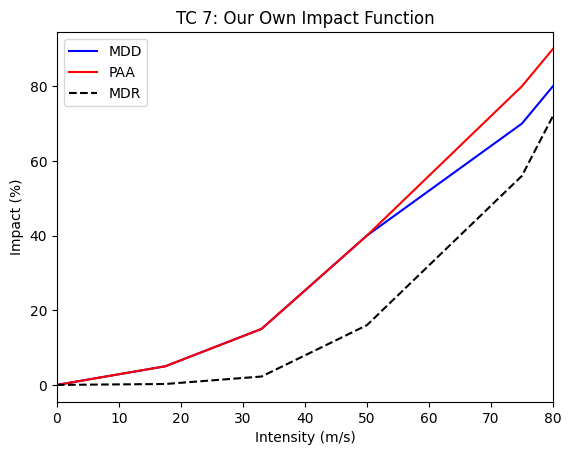

In [40]:
import numpy as np
from climada.entity import ImpactFunc

# We initialise a dummy ImpactFunc for tropical cyclone wind damage to building.
haz_type = "TC"
id = 7
name = "Our Own Impact Function"
# provide unit of the hazard intensity
intensity_unit= "m/s"

intensity = np.array([0, 17.5, 33, 50, 75, 80])
mdd = np.array([0, 0.05, 0.15, 0.4, 0.7, 0.8])
paa = np.array([0, 0.05, 0.15, 0.4, 0.8, 0.9])

impf_phl = ImpactFunc(
    id=id,
    name=name,
    intensity_unit=intensity_unit,
    haz_type=haz_type,
    intensity=intensity,
    mdd=mdd,
    paa=paa,
)


impf_pnt = ImpactFuncSet()
impf_pnt.append(impf_phl)
# check if the all the attributes are set correctly
impf_pnt.check()
# plot impact function
impf_pnt.plot();

# **2.2 Do the Impact Function here**

Nearest neighbor hazard.centroids indexes for each exposure: [ 39401  20725 168200  41701 172086  66653 192373 194676  19860 149284
  13730   9193  23773  51845  15926  86934 110260  15925  43314  19828
  56545  93297  35943  95443  21581   2425  53833  39049 190720   6652
  82625 129739 132373 102507  34626  81447  56739 159637  57339 144569
  34744  16703 148469  89207   1381 109466 101284  71521 193698  32433
 159666  86175  73662 127676 117275  97775  92674 119594  16979  95624
 142478  50975  56791 149245 189785 150284  83916 146429  99432  10543
 107258  24790  62854   6843  96235 102606  79500 154996  54629 133160
 116468 165911   2945  11502 194608 102652  93267  75293 111195 189226
  46825  92716 148468 114519  89348  89348 174478  17209  45281 157019
  45320 139118 133663 186813  69066  21112 115304  84937  27015  17219
 105588 111198  18317  84559 185306  16727   9040  11526   2175 150318
   4246  28913  90299  59875  98934 179140  31247 142995 179839  50738
 130503  44148 1

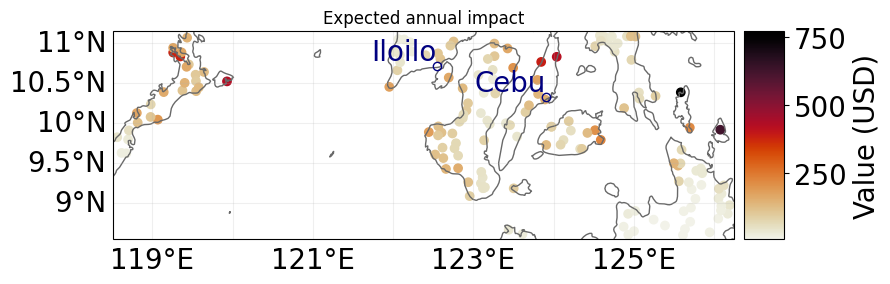

In [41]:
# Step 6: Assign impact function ID to exposures
haz_type = "TC"
haz_id = 7  # Philippines-specific impact function
# Rename 'Exposure_1' to 'value'
exp_lp.gdf.rename(columns={"Exposure_1": "value"}, inplace=True)
exp_lp.gdf.rename(columns={"impf_": f"impf_{haz_type}"}, inplace=True)
exp_lp.gdf[f"impf_{haz_type}"] = haz_id
exp_lp.check()

# Step 7: Compute economic impact tcpnt
imp_pnt = ImpactCalc(exp_lp, impf_pnt, tc_pnt).impact(save_mat=True)


print(
    "Nearest neighbor hazard.centroids indexes for each exposure:",
    exp_lp.gdf["centr_TC"].values,
)
imp_pnt.plot_scatter_eai_exposure(ignore_zero=False, buffer=0.05);

# Step 8: Output results
print(f"Total Economic Impact (USD): {imp_pnt.aai_agg:,.2f}")
print(f"Impact per event (USD): {imp_pnt.at_event[0]:,.2f}")
print(f"Sum of the direct impact at all exposure point: {imp_pnt.eai_exp.sum():,.2f}")
print(f"total exposure value affected (USD): {imp_pnt.tot_value.sum():,.2f}")